<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Support Vector Machine (SVM)**


In this lab, you will learn how Support Vector Machine (SVM) models work and practice using them for classification.
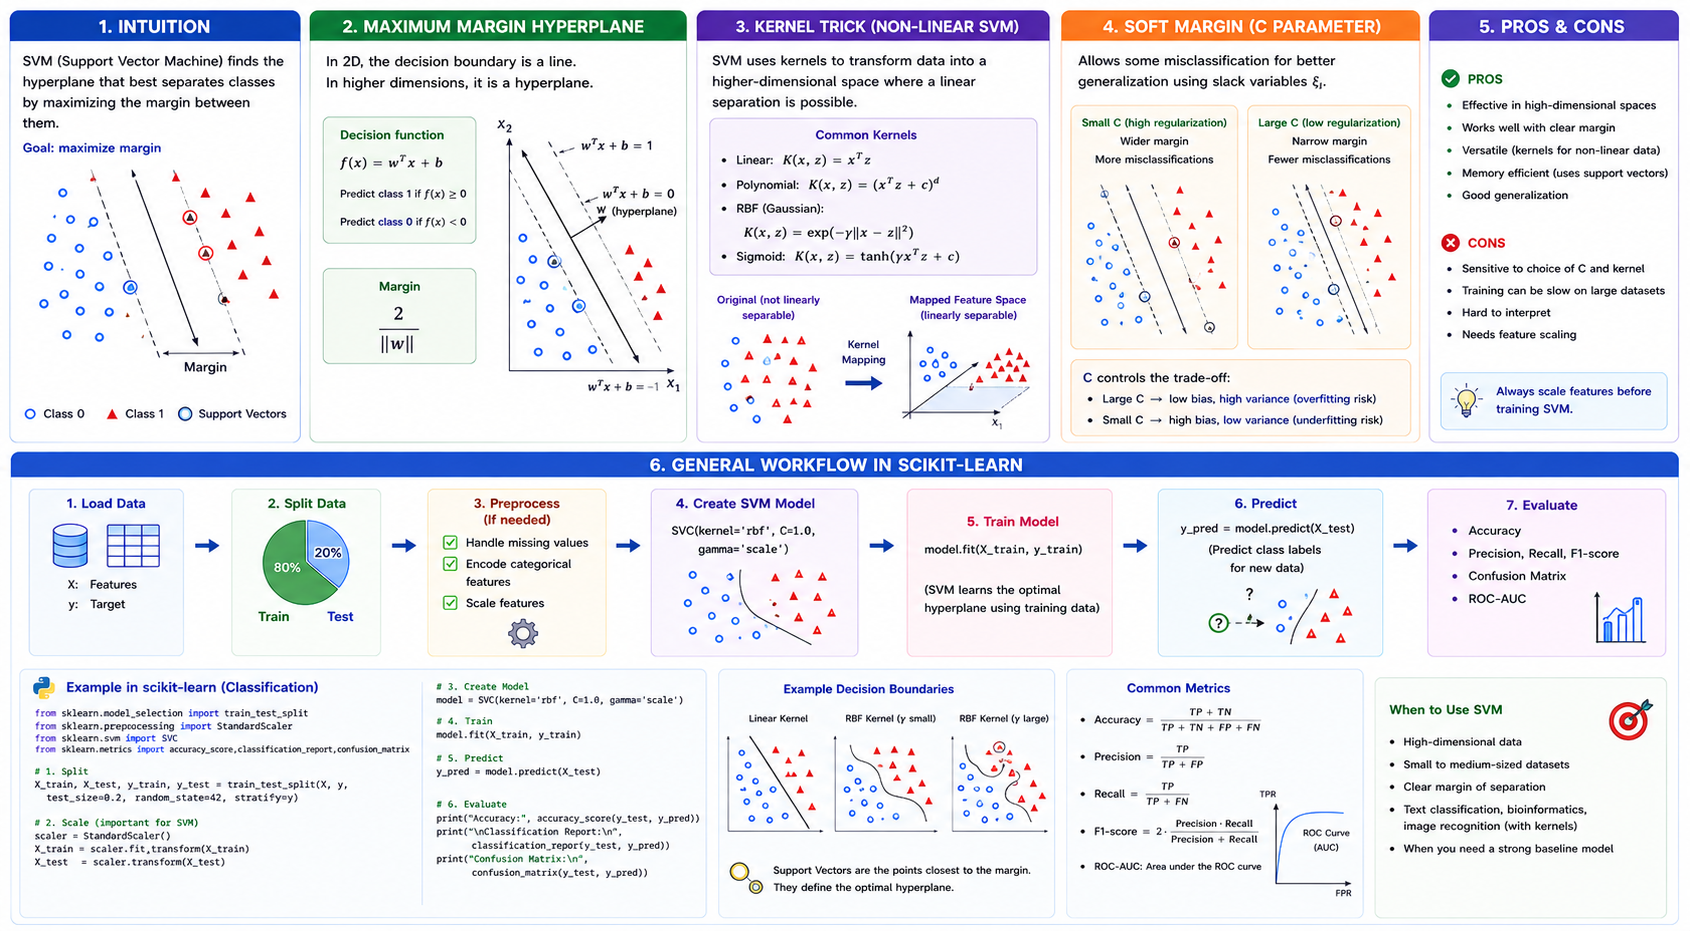

## **Introduction**

SVM is a classification model that tries to find the best boundary between classes. For a linear SVM, this boundary is called a **hyperplane**:

$$
w^Tx + b = 0
$$

The model predicts the class based on which side of the hyperplane a sample falls on:

$$
\hat{y} = \text{sign}(w^Tx + b)
$$

SVM chooses the hyperplane with the largest **margin**, which means the boundary is as far as possible from the closest training points. Those closest points are called **support vectors** because they determine the position of the boundary.

The distance from a sample $x$ to the hyperplane is:

$$
\text{distance} = \frac{|w^Tx + b|}{\lVert w \rVert}
$$

During training, SVM uses **hinge loss**. Hinge loss is zero when a point is correctly classified with enough margin. It becomes larger when a point is inside the margin or on the wrong side of the boundary.

For labels $y_i \in \{-1, 1\}$, the hinge loss for one training sample is:

$$
L_i = \max(0, 1 - y_i(w^Tx_i + b))
$$

The SVM cost function combines margin size and classification errors:

$$
J(w, b) = \frac{1}{2}\lVert w \rVert^2 + C\sum_{i=1}^{m}\max(0, 1 - y_i(w^Tx_i + b))
$$

The first term, $\frac{1}{2}\lVert w \rVert^2$, encourages a wider margin. The second term penalizes points that are misclassified or too close to the boundary.

The regularization parameter `C` controls this tradeoff:

- Larger `C`: fewer training errors, but a smaller margin and higher overfitting risk.
- Smaller `C`: wider margin, but more training errors may be allowed.


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/module3_svm/images/svm.png" width="720" alt="evaluation metrics">
</center>


## **Gaussian RBF Kernel**
A linear SVM separates classes with a straight boundary, or **hyperplane**. This works well when the classes can be separated by a straight line in 2-D, a plane in 3-D, or a hyperplane in higher dimensions. The linear SVM uses $w^Tx + b$ to draw this boundary in the original feature space.

If the classes cannot be separated well with a straight boundary, SVM can use a **kernel**. Instead of separating data directly in the original low-dimensional space, we imagine mapping it into a higher-dimensional space where a linear boundary may work better. The kernel measures similarity between samples in that transformed space, allowing the boundary to bend around more complex class patterns in the original space.

The prediction can be written as:

$$
f(x) = \sum_i \alpha_i y_i K(x_i, x) + b
$$

In this formula:

- $x$ is the new sample we want to classify.
- $x_i$ is one training sample.
- $y_i$ is the class label of training sample $x_i$. This is the target value we are trying to predict, not another feature vector.
- $\alpha_i$ tells how important training sample $x_i$ is for the final decision.
- $K(x_i, x)$ measures similarity between the training sample $x_i$ and the new sample $x$.

For the Gaussian Radial Basis Function (RBF) kernel, the similarity is:

$$
K(x_i, x) = \exp(-\gamma \lVert x_i - x \rVert^2)
$$

This is called the **kernel trick** because SVM can act like it is working in a higher-dimensional feature space without explicitly creating those transformed features.


To see how a kernel can represent a higher-dimensional transformation, let's look at a simpler polynomial kernel example.

Suppose we have two input vectors $x = (x_{1}, x_{2})$ and $z = (z_{1}, z_{2})$. Here, $z$ is just another feature vector. 


A simple polynomial kernel is:


$$K(x, z) = (x^Tz)^2$$


If we apply the kernel to vectors $x$ and $z$, we get:


$$K(x, z) = (x^Tz)^2 = (x_{1}z_{1} + x_{2}z_{2})^2 = x_{1}^2z_{1}^2 + x_{2}^2z_{2}^2 + 2x_{1}x_{2}z_{1}z_{2}$$


This is the same as taking a dot product between two transformed 3-dimensional vectors:


$$\phi(x) = (x_{1}^2, x_{2}^2, \sqrt{2}x_{1}x_{2}) $$


$$\phi(z) = (z_{1}^2, z_{2}^2, \sqrt{2}z_{1}z_{2})$$


So, computing $K(x, z)$ gives the same result as transforming both vectors first and then taking the dot product $\phi(x)^T\phi(z)$. The useful part is that SVM can get this result without explicitly building the transformed features.


## **Objectives**


We will use a diabetes food recommendation dataset that contains nutrition information for food items. This dataset is similar to the `food_items.csv` dataset used in the logistic regression lab (**3.1.1**), which has three target classes. However, in this SVM lab, we use the binary version of the dataset, `food_items_binary.csv`, which has two target classes: `Less Often` and `More Often`.

The objective is to classify whether a person with diabetes should choose a food item `More Often` or `Less Often` based on its nutrient values.

* Train and evaluate SVM classifiers
* Tune important SVM hyperparameters, including `C` and `kernel`
* Plot decision boundaries and margins from trained SVM models


***


## **Workflow**
### **Set Up the Lab Environment**


In [2]:
# Import required packages
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from imblearn.under_sampling import RandomUnderSampler
from sklearn import metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_recall_fscore_support, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

In [3]:
# Set a random seed for reproducible results
rs = 123

### **Load and Explore the Dataset**


First, load the dataset as a Pandas DataFrame and review its basic structure.


In [4]:
# Load the dataset
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/datasets/food_items_binary.csv"
food_df = pd.read_csv(dataset_url)

Next, look at the first five rows of the dataset.


In [5]:
food_df.head(10)

,Calories,Total Fat,Saturated Fat,Monounsaturated Fat,Polyunsaturated Fat,Trans Fat,Cholesterol,Sodium,Total Carbohydrate,Dietary Fiber,Sugars,Sugar Alcohol,Protein,Vitamin A,Vitamin C,Calcium,Iron,class
0,149.0,0,0.0,0.0,0.0,0.0,0,9.0,9.8,0.0,0.0,0,1.3,0,0,0,0,0
1,123.0,0,0.0,0.0,0.0,0.0,0,5.0,6.6,0.0,0.0,0,0.8,0,0,0,0,0
2,150.0,0,0.0,0.0,0.0,0.0,0,4.0,11.4,0.0,0.0,0,1.3,0,0,0,0,0
3,110.0,0,0.0,0.0,0.0,0.0,0,6.0,7.0,0.0,0.0,0,0.8,0,0,0,0,0
4,143.0,0,0.0,0.0,0.0,0.0,0,7.0,13.1,0.0,0.0,0,1.0,0,0,0,0,0
5,110.0,0,0.0,0.0,0.0,0.0,0,6.0,7.0,0.0,0.0,0,0.8,0,0,0,0,0
6,142.0,0,0.0,0.0,0.0,0.0,0,12.0,10.6,0.0,0.0,0,1.2,0,0,0,0,0
7,102.0,0,0.0,0.0,0.0,0.0,0,13.0,5.0,0.0,0.0,0,0.7,0,0,0,0,0
8,145.0,0,0.0,0.0,0.0,0.0,0,17.0,11.0,0.0,0.0,0,1.2,0,0,0,0,0
9,171.0,0,0.0,0.0,0.0,0.0,0,8.0,13.7,0.0,0.0,0,2.5,0,0,0,0,0


In [6]:
# Use all columns except the target column as input features
feature_cols = list(food_df.iloc[:, :-1].columns)
feature_cols

['Calories',
 'Total Fat',
 'Saturated Fat',
 'Monounsaturated Fat',
 'Polyunsaturated Fat',
 'Trans Fat',
 'Cholesterol',
 'Sodium',
 'Total Carbohydrate',
 'Dietary Fiber',
 'Sugars',
 'Sugar Alcohol',
 'Protein',
 'Vitamin A',
 'Vitamin C',
 'Calcium',
 'Iron']

In [7]:
X = food_df.iloc[:, :-1]
y = food_df.iloc[:, -1]

In [8]:
X.describe()

,Calories,Total Fat,Saturated Fat,Monounsaturated Fat,Polyunsaturated Fat,Trans Fat,Cholesterol,Sodium,Total Carbohydrate,Dietary Fiber,Sugars,Sugar Alcohol,Protein,Vitamin A,Vitamin C,Calcium,Iron
count,7639.000000,7639.000000,7639.000000,7639.000000,7639.000000,7639.000000,7639.000000,7639.000000,7639.000000,7639.000000,7639.000000,7639.000000,7639.000000,7639.000000,7639.000000,7639.000000,7639.000000
mean,105.098835,2.318235,0.368920,0.309216,0.264116,0.007069,4.308679,235.053659,15.510719,1.806074,3.734756,0.059039,4.298975,6.636733,6.487237,3.937688,5.510014
std,77.224368,3.438941,0.737164,1.310260,2.848250,0.094783,14.788162,252.438163,14.028570,4.099947,5.013685,0.771173,5.349881,19.658111,19.566500,7.892694,9.855960
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,3.700000,0.000000,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000
50%,100.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,13.000000,1.000000,2.000000,0.000000,3.000000,0.000000,0.000000,0.000000,2.000000
75%,140.000000,3.000000,0.500000,0.000000,0.000000,0.000000,0.000000,375.500000,24.000000,3.000000,5.000000,0.000000,6.000000,6.000000,4.000000,4.000000,8.000000
max,2210.000000,24.000000,8.000000,16.800000,235.000000,2.500000,450.000000,2220.000000,270.000000,305.000000,39.000000,19.000000,70.000000,370.000000,280.000000,110.000000,100.000000


The dataset contains 17 nutrition features for each food item, including calories, total fat, protein, sugars, and other nutrient values. All feature columns are numeric.


Next, check the target variable, `class`, to see the label values and their distribution.


In [9]:
# Use the `class` column as the target variable
y.value_counts(normalize=True)

class
0    0.870402
1    0.129598
Name: proportion, dtype: float64

<Axes: xlabel='class'>

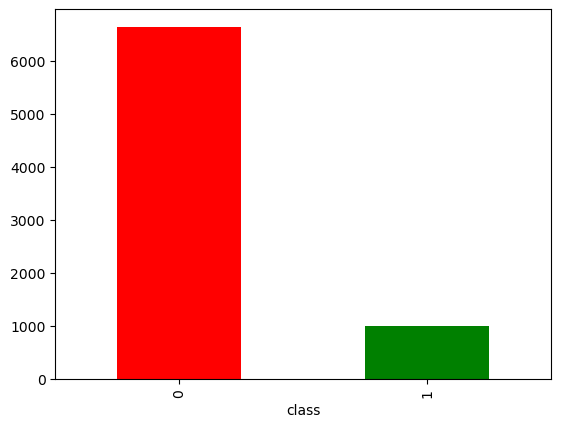

In [10]:
y.value_counts().plot.bar(color=['red', 'green'])

The bar chart shows two classes: `Less Often` and `More Often`. The classes are imbalanced because most food items are labeled `Less Often` for people with diabetes.


### **Build an SVM Model with Default Parameters**


First, split the data into training and testing sets. The training set is used to train the model, and the testing set is used to evaluate final model performance. For larger projects, you may also create a validation set for model tuning.


In [11]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state = rs)

Now that the training and testing sets are ready, we can train the first SVM model.


First, define an `SVC` model from `sklearn.svm` using the default settings.


In [12]:
model = SVC()

Train the model with the training data.


In [13]:
model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


Next, use the trained model to make predictions on the test data.


In [14]:
preds = model.predict(X_test)

The function below evaluates model performance using common classification metrics.


In [15]:
def evaluate_metrics(yt, yp):
    results_pos = {}
    results_pos['accuracy'] = accuracy_score(yt, yp)
    precision, recall, f_beta, _ = precision_recall_fscore_support(yt, yp, average='binary')
    results_pos['recall'] = recall
    results_pos['precision'] = precision
    results_pos['f1score'] = f_beta
    return results_pos

In [16]:
evaluate_metrics(y_test, preds)

{'accuracy': 0.9568062827225131,
 'recall': 0.7727272727272727,
 'precision': 0.8793103448275862,
 'f1score': 0.8225806451612904}

The default SVM model performs well on this binary classification task. It reaches about `0.95` accuracy and an F1-score of about `0.82`.


The default SVM model already performs well, but we may improve performance by tuning its hyperparameters.


### **Train SVM Models with `C` Values and Kernels**


The `SVC` model has two important hyperparameters to tune: the regularization parameter `C` and the `kernel`.


The `C` parameter controls the trade-off between reducing training errors and keeping the decision boundary simple.

* A larger `C` tries harder to classify the training points correctly. This can improve training performance, but it may also lead to overfitting.
* A smaller `C` allows more training errors so the model can keep a wider margin. This may improve generalization to new data.


The `kernel` parameter controls how SVM represents the decision boundary. Common nonlinear kernels include:

* `rbf`: Gaussian Radial Basis Function kernel
* `poly`: Polynomial kernel
* `sigmoid`: Sigmoid kernel


First, try `C=10` and `kernel='rbf'`.


In [17]:
model = SVC(C=10, kernel='rbf')
model.fit(X_train, y_train)
preds = model.predict(X_test)
evaluate_metrics(y_test, preds)

{'accuracy': 0.9679319371727748,
 'recall': 0.8333333333333334,
 'precision': 0.9116022099447514,
 'f1score': 0.8707124010554089}

This model performs better than the default SVM model from the previous step. Next, try different parameter values yourself.


#### **Coding Exercise**
Try different values of `C` and different `kernel` functions to find the SVM model with the best classification performance.


In [18]:
# Train and evaluate an SVM model with selected hyperparameters
model = SVC(C=100, kernel='rbf')
model.fit(X_train, y_train)
preds = model.predict(X_test)
evaluate_metrics(y_test, preds)

{'accuracy': 0.9698952879581152,
 'recall': 0.8787878787878788,
 'precision': 0.8877551020408163,
 'f1score': 0.883248730964467}

#### **Tune `C` and Kernel with GridSearchCV**


Manually trying every combination of hyperparameters can take a lot of time. Instead, we can use `GridSearchCV` from `sklearn` to test several combinations automatically.


`GridSearchCV` trains and evaluates each model combination using cross-validation. It then selects the parameter combination with the best score.


First, we define the candidate values for `C` and `kernel` in a dictionary. `GridSearchCV` will test every combination of these values.


In [19]:
params_grid = {
    'C': [1, 10, 100],
    'kernel': ['poly', 'rbf', 'sigmoid']
}

Create the SVM model that we want to tune.


In [20]:
model = SVC()

Then create a `GridSearchCV` object. It searches through `params_grid` and chooses the combination with the best F1-score. This search may take several minutes to complete.


In [21]:
# Define GridSearchCV to search for the best parameters
grid_search = GridSearchCV(estimator = model, 
                           param_grid = params_grid, 
                           scoring='f1',
                           cv = 5, 
                           verbose = 1)
# Fit the grid search on the training data
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_

Fitting 5 folds for each of 9 candidates, totalling 45 fits


In [22]:
best_params

{'C': 100, 'kernel': 'rbf'}

The grid search shows that `C=100` and `kernel='rbf'` produce the highest F1-score. Next, we train an SVM model with this combination and evaluate its performance.


In [23]:
# Use the best fitted SVM model from GridSearchCV
best_model = grid_search.best_estimator_
preds = best_model.predict(X_test)
evaluate_metrics(y_test, preds)

{'accuracy': 0.9698952879581152,
 'recall': 0.8787878787878788,
 'precision': 0.8877551020408163,
 'f1score': 0.883248730964467}

In [24]:
print(classification_report(y_test, preds))


              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1330
           1       0.89      0.88      0.88       198

    accuracy                           0.97      1528
   macro avg       0.93      0.93      0.93      1528
weighted avg       0.97      0.97      0.97      1528



After hyperparameter tuning, the best F1-score improves to about `0.88`.


**Findings:**
>The best SVM model uses all nutrition features and performs well on the binary food recommendation task. GridSearchCV selected the RBF kernel, which means a curved decision boundary worked better than a straight-line boundary. This suggests that the relationship between nutrition values and the food recommendation class is not purely linear. However, the RBF SVM does not provide simple feature coefficients, so it is harder to explain which individual nutrients are most important compared with logistic regression.


### **Visualize the SVM Decision Boundary and Margin**


So far, we have trained, evaluated, and tuned SVM models with `sklearn`. The evaluation metrics tell us how well the model performs, but they do not show how the model separates the classes. In this section, we will visualize the SVM decision boundary.


A hyperplane is hard to visualize when the dataset has many features. To make the idea easier to see, we will use only two features and plot the boundary in 2-D.


First, we simplify the dataset by keeping only two features: `Calories` and `Dietary Fiber`. We also use the first 1000 rows to keep the plot easier to read.


In [25]:
simplified_food_df = food_df[['Calories', 'Dietary Fiber', 'class']]

In [26]:
fields = ['Calories', 'Dietary Fiber']
X = simplified_food_df.loc[:999, fields]
y = simplified_food_df.loc[:999, 'class']

Next, we undersample the majority class, `Class = 0`, to make the two classes more balanced. This helps make the decision boundary easier to see.


In [27]:
under_sampler = RandomUnderSampler(random_state=rs)
X_under, y_under = under_sampler.fit_resample(X, y)
X_under = X_under.reset_index(drop=True)
y_under = y_under.reset_index(drop=True)

In [28]:
print(f"Dataset resampled shape, X: {X_under.shape}, y: {y_under.shape}")

Dataset resampled shape, X: (62, 2), y: (62,)


Next, normalize the two features with `MinMaxScaler`. This puts both features on the same 0-to-1 scale, which helps the SVM model and makes the plot easier to interpret.


In [29]:
scaler = MinMaxScaler()
X_under = pd.DataFrame(scaler.fit_transform(X_under), columns=fields)

#### **`kernel='linear'`**

First, train a linear SVM model with `kernel='linear'`. A linear SVM creates a straight decision boundary in this 2-D feature space.


In [30]:
linear_svm = SVC(C=1000, kernel='linear')
linear_svm.fit(X_under, y_under)

,C,1000
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


The function below plots the decision boundary. The background color shows the predicted class for each point on the grid, and the scattered points show the actual samples.


In [31]:
def plot_decision_boundary(X, y, estimator):
    estimator.fit(X, y)

    X_color = X.sample(min(300, len(X)), random_state=rs)
    y_color = y.loc[X_color.index]
    y_color = y_color.map(lambda r: 'red' if r == 1 else 'yellow')

    x_axis = np.arange(0, 1, .005)
    y_axis = np.arange(0, 1, .005)
    xx, yy = np.meshgrid(x_axis, y_axis)
    X_grid = pd.DataFrame({fields[0]: xx.ravel(), fields[1]: yy.ravel()})
    y_grid_predictions = estimator.predict(X_grid)
    y_grid_predictions = y_grid_predictions.reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.contourf(xx, yy, y_grid_predictions, cmap=plt.cm.autumn_r, alpha=.3)
    ax.scatter(X_color.iloc[:, 0], X_color.iloc[:, 1], color=y_color, alpha=1)
    ax.set(
        xlabel=fields[0],
        ylabel=fields[1],
        title=str(estimator)
    )
    plt.show()

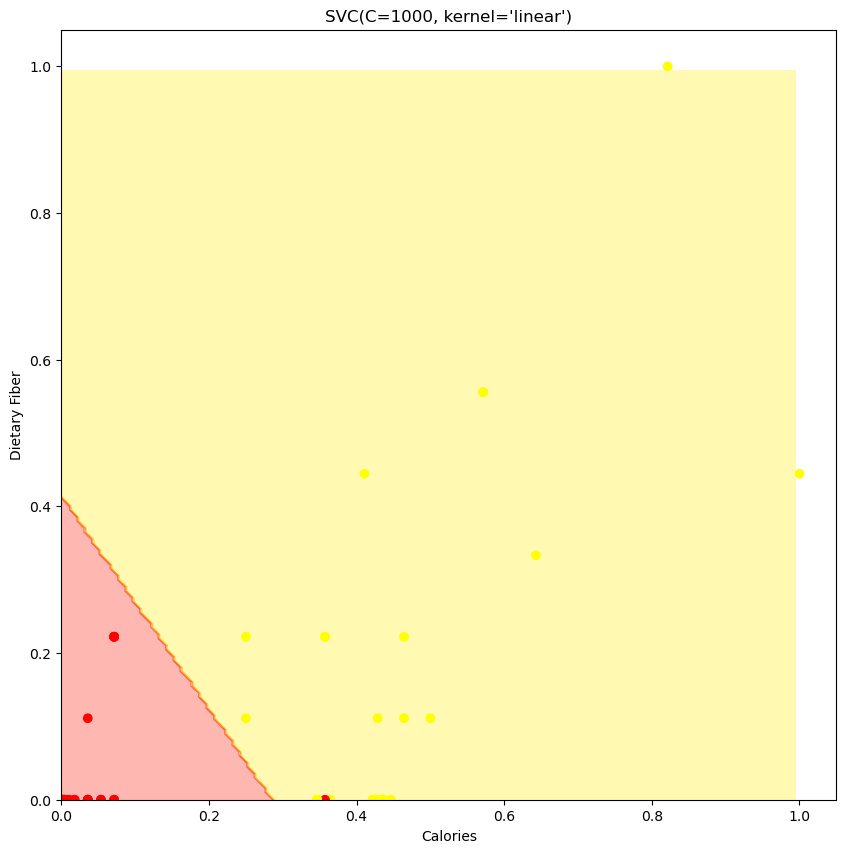

In [32]:
plot_decision_boundary(X_under, y_under, linear_svm)

**Findings:**

>The linear-kernel SVM creates a straight decision boundary. In this two-feature plot, it separates the small red region in the lower-left area from the larger yellow region. This means the linear model is using a simple rule based on `Calories` and `Dietary Fiber`, but it may be too simple if the true class pattern is curved.


#### **`kernel='rbf'`**

Next, we use an RBF kernel. The RBF kernel can create a curved decision boundary in the original 2-D feature space. This can help when the classes cannot be separated well by a straight line.


In [33]:
svm_rbf_kernel = SVC(C=100, kernel='rbf')
svm_rbf_kernel.fit(X_under, y_under)

,C,100
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


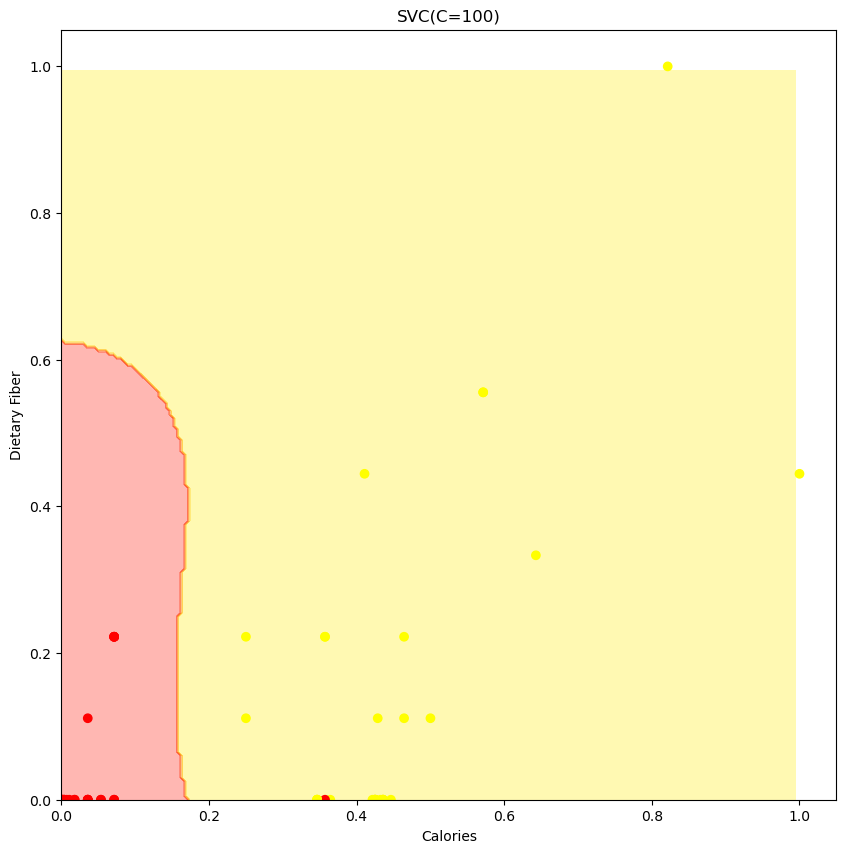

In [34]:
plot_decision_boundary(X_under, y_under, svm_rbf_kernel)

**Findings:**

>The RBF-kernel SVM creates a curved decision boundary. Compared with the linear model, it gives the red class a smoother nonlinear region on the left side of the plot. This shows that the RBF kernel can capture more flexible class patterns than a straight-line boundary.


#### **`kernel='poly'`**

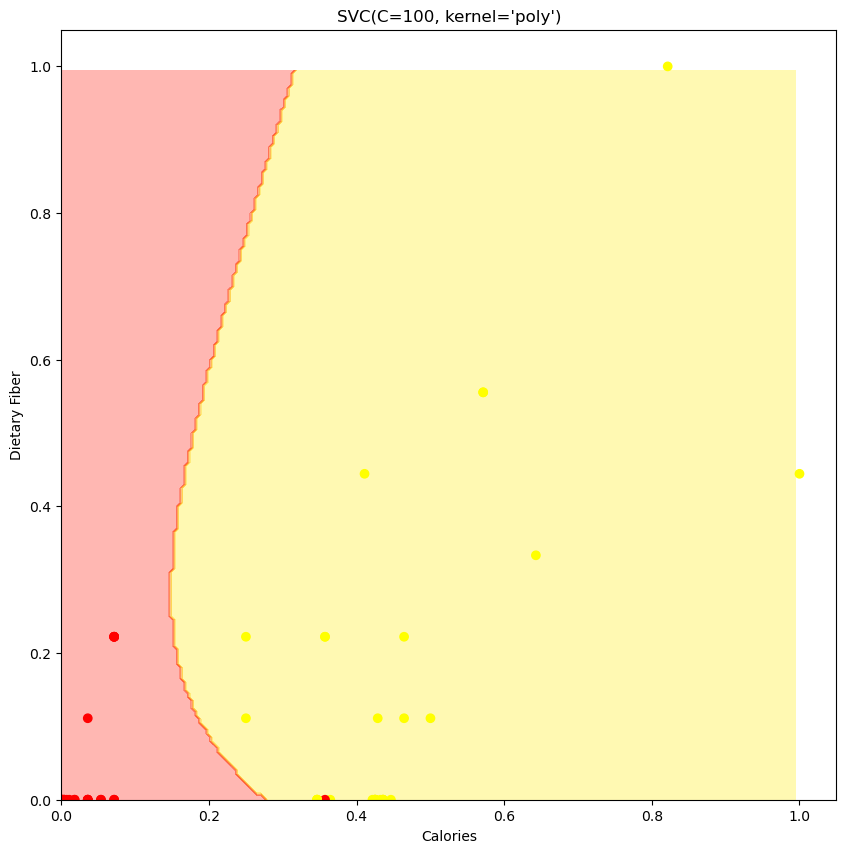

In [35]:
# Train and visualize a polynomial-kernel SVM model
svm_poly_kernel = SVC(C=100, kernel='poly')
svm_poly_kernel.fit(X_under, y_under)
plot_decision_boundary(X_under, y_under, svm_poly_kernel)

**Findings:**

>The polynomial-kernel SVM also creates a curved decision boundary. Most samples on the right side of the plot are classified as the yellow class, while a smaller region on the left is classified as the red class. In this example, the polynomial boundary is nonlinear but still fairly simple, and the split is mainly driven by `Calories`.


**Conclusion:**

>Across the three kernels, the linear model gives the simplest boundary, while the RBF and polynomial kernels create more flexible curved boundaries. For this two-feature visualization, all three models separate the same general regions, but the RBF and polynomial kernels are better choices when the class pattern is not well described by a straight line. The full model evaluation earlier also selected `kernel='rbf'`, so RBF is the strongest choice in this lab.


## **Authors**


[Yan Luo](https://www.linkedin.com/in/yan-luo-96288783/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML241ENSkillsNetwork31576874-2021-01-01)
Su Wu

Copyright © 2021 IBM Corporation. All rights reserved.
